<a href="https://colab.research.google.com/github/gerald-hlabiso/business-analytics-portfolio/blob/main/projects/employee-turnover-workforce-analytics/employee-turnover-workforce-analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Dataset

This project uses the **IBM HR Analytics Employee Attrition & Performance** dataset, a fictional workforce dataset created for analytics practice.

The dataset contains:

- **1,470 employee records**
- **35 variables**
- employee demographics, compensation, travel, job role, satisfaction, experience, and workplace conditions
- a binary attrition outcome

Because the data is fictional, findings demonstrate analytical methods and should not be interpreted as verified evidence about IBM employees or any real organization.

## Outcome

The target variable is `Attrition`:

- `Yes` — the employee left the organization
- `No` — the employee remained with the organization

The target will be encoded as:

- `1` — attrition
- `0` — retention

This is an imbalanced binary-classification problem.

## Responsible-Use Statement

This notebook is an educational workforce-analytics demonstration. Predictive associations do not establish causation.

The model must not be used to discipline, terminate, deny promotion to, or otherwise make adverse employment decisions about individual employees. Any real organizational use would require stronger data governance, privacy safeguards, fairness testing, legal review, stakeholder consultation, and validation using current organizational data.


In [1]:
# Install the additional package required for the GAM model.
!pip install -q pygam

# Core data libraries
import os
import random
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep"
)

warnings.filterwarnings("ignore")

print("Environment configured successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 1.3 MB/s eta 0:00:00
Environment configured successfully.


In [10]:
# Download and load the IBM HR Analytics Employee Attrition dataset

!pip install -q kagglehub

from pathlib import Path
import kagglehub

dataset_directory = Path(
    kagglehub.dataset_download(
        "pavansubhasht/ibm-hr-analytics-attrition-dataset"
    )
)

csv_files = list(dataset_directory.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        "No CSV file was found in the downloaded dataset."
    )

DATA_PATH = csv_files[0]
df = pd.read_csv(DATA_PATH)

required_columns = {
    "Attrition",
    "Age",
    "Department",
    "JobRole",
    "MonthlyIncome",
    "OverTime"
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Required IBM HR columns are missing: {sorted(missing_columns)}"
    )

if df.shape != (1470, 35):
    raise ValueError(
        f"Unexpected dataset dimensions: {df.shape}. "
        "Expected 1,470 rows and 35 columns."
    )

print("=" * 70)
print("IBM HR DATASET LOADED SUCCESSFULLY")
print("=" * 70)
print(f"File: {DATA_PATH.name}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Missing values: {df.isna().sum().sum():,}")
print(f"Duplicate rows: {df.duplicated().sum():,}")
print("\nAttrition distribution:")
print(df["Attrition"].value_counts())

display(df.head())

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
IBM HR DATASET LOADED SUCCESSFULLY
File: WA_Fn-UseC_-HR-Employee-Attrition.csv
Rows: 1,470
Columns: 35
Missing values: 0
Duplicate rows: 0

Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [11]:
# IBM HR data-quality audit and modeling-table preparation

raw_df = df.copy()

# Encode the outcome
raw_df["AttritionFlag"] = (
    raw_df["Attrition"]
    .map({"No": 0, "Yes": 1})
)

if raw_df["AttritionFlag"].isna().any():
    raise ValueError(
        "Unexpected values were found in the Attrition column."
    )

# Identify columns that contain no useful variation
constant_columns = [
    column
    for column in raw_df.columns
    if raw_df[column].nunique(dropna=False) <= 1
]

# EmployeeNumber is an identifier, not a meaningful predictor
identifier_columns = ["EmployeeNumber"]

# Create the modeling dataset
model_df = raw_df.drop(
    columns=[
        "Attrition",
        *constant_columns,
        *identifier_columns
    ]
).copy()

TARGET = "AttritionFlag"

categorical_features = (
    model_df
    .drop(columns=TARGET)
    .select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

numeric_features = (
    model_df
    .drop(columns=TARGET)
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

attrition_counts = (
    raw_df["Attrition"]
    .value_counts()
    .reindex(["No", "Yes"])
)

attrition_rate = raw_df["AttritionFlag"].mean()

audit_summary = pd.DataFrame({
    "Metric": [
        "Original rows",
        "Original columns",
        "Missing values",
        "Duplicate rows",
        "Employees retained",
        "Employees with attrition",
        "Attrition rate",
        "Constant columns removed",
        "Identifier columns removed",
        "Modeling predictors",
        "Numeric predictors",
        "Categorical predictors"
    ],
    "Value": [
        f"{raw_df.shape[0]:,}",
        f"{df.shape[1]:,}",
        f"{raw_df.isna().sum().sum():,}",
        f"{raw_df.duplicated().sum():,}",
        f"{attrition_counts['No']:,}",
        f"{attrition_counts['Yes']:,}",
        f"{attrition_rate:.1%}",
        ", ".join(constant_columns),
        ", ".join(identifier_columns),
        model_df.shape[1] - 1,
        len(numeric_features),
        len(categorical_features)
    ]
})

print("=" * 75)
print("IBM HR DATA-QUALITY AUDIT")
print("=" * 75)

display(audit_summary)

print("\nCategorical predictors:")
print(categorical_features)

print("\nNumeric predictors:")
print(numeric_features)

assert model_df[TARGET].isin([0, 1]).all()
assert "EmployeeNumber" not in model_df.columns
assert not any(
    column in model_df.columns
    for column in constant_columns
)

print("\nModeling table prepared successfully.")

IBM HR DATA-QUALITY AUDIT


,Metric,Value
0,Original rows,"1,470"
1,Original columns,35
2,Missing values,0
3,Duplicate rows,0
4,Employees retained,"1,233"
5,Employees with attrition,237
6,Attrition rate,16.1%
7,Constant columns removed,"EmployeeCount, Over18, StandardHours"
8,Identifier columns removed,EmployeeNumber
9,Modeling predictors,30



Categorical predictors:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numeric predictors:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Modeling table prepared successfully.


## 1. Workforce Attrition Profile

The outcome distribution is examined before modeling. Because employees with attrition represent a minority of the dataset, accuracy alone would overstate model performance.

The analysis therefore emphasizes class-sensitive measures including precision, recall, F1 score, PR-AUC, ROC-AUC, and probability calibration.


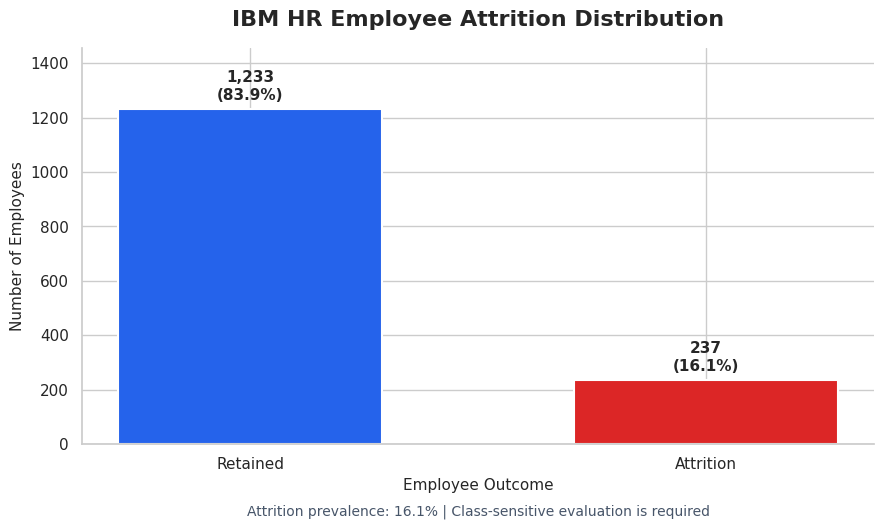

Saved: /content/employee-turnover-portfolio-visuals/attrition-class-distribution.png


In [12]:
# Create the portfolio-visual folder

from pathlib import Path

OUTPUT_DIR = Path("/content/employee-turnover-portfolio-visuals")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

class_counts = (
    raw_df["Attrition"]
    .value_counts()
    .reindex(["No", "Yes"])
    .rename(index={
        "No": "Retained",
        "Yes": "Attrition"
    })
)

class_percentages = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(9, 5.5))

colors = ["#2563EB", "#DC2626"]

bars = ax.bar(
    class_counts.index,
    class_counts.values,
    color=colors,
    width=0.58,
    edgecolor="white",
    linewidth=1.5
)

for bar, count, percentage in zip(
    bars,
    class_counts.values,
    class_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 22,
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "IBM HR Employee Attrition Distribution",
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Employee Outcome", fontsize=11)
ax.set_ylabel("Number of Employees", fontsize=11)
ax.set_ylim(0, class_counts.max() * 1.18)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.text(
    0.5,
    -0.18,
    f"Attrition prevalence: {class_percentages['Attrition']:.1f}% | "
    "Class-sensitive evaluation is required",
    transform=ax.transAxes,
    ha="center",
    fontsize=10,
    color="#475569"
)

plt.tight_layout()

chart_path = OUTPUT_DIR / "attrition-class-distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")

## 2. Exploratory Workforce Analysis

Attrition rates are compared across overtime status, business travel, job level, and marital status. These comparisons identify descriptive patterns for further modeling, but they do not prove that any characteristic causes attrition.

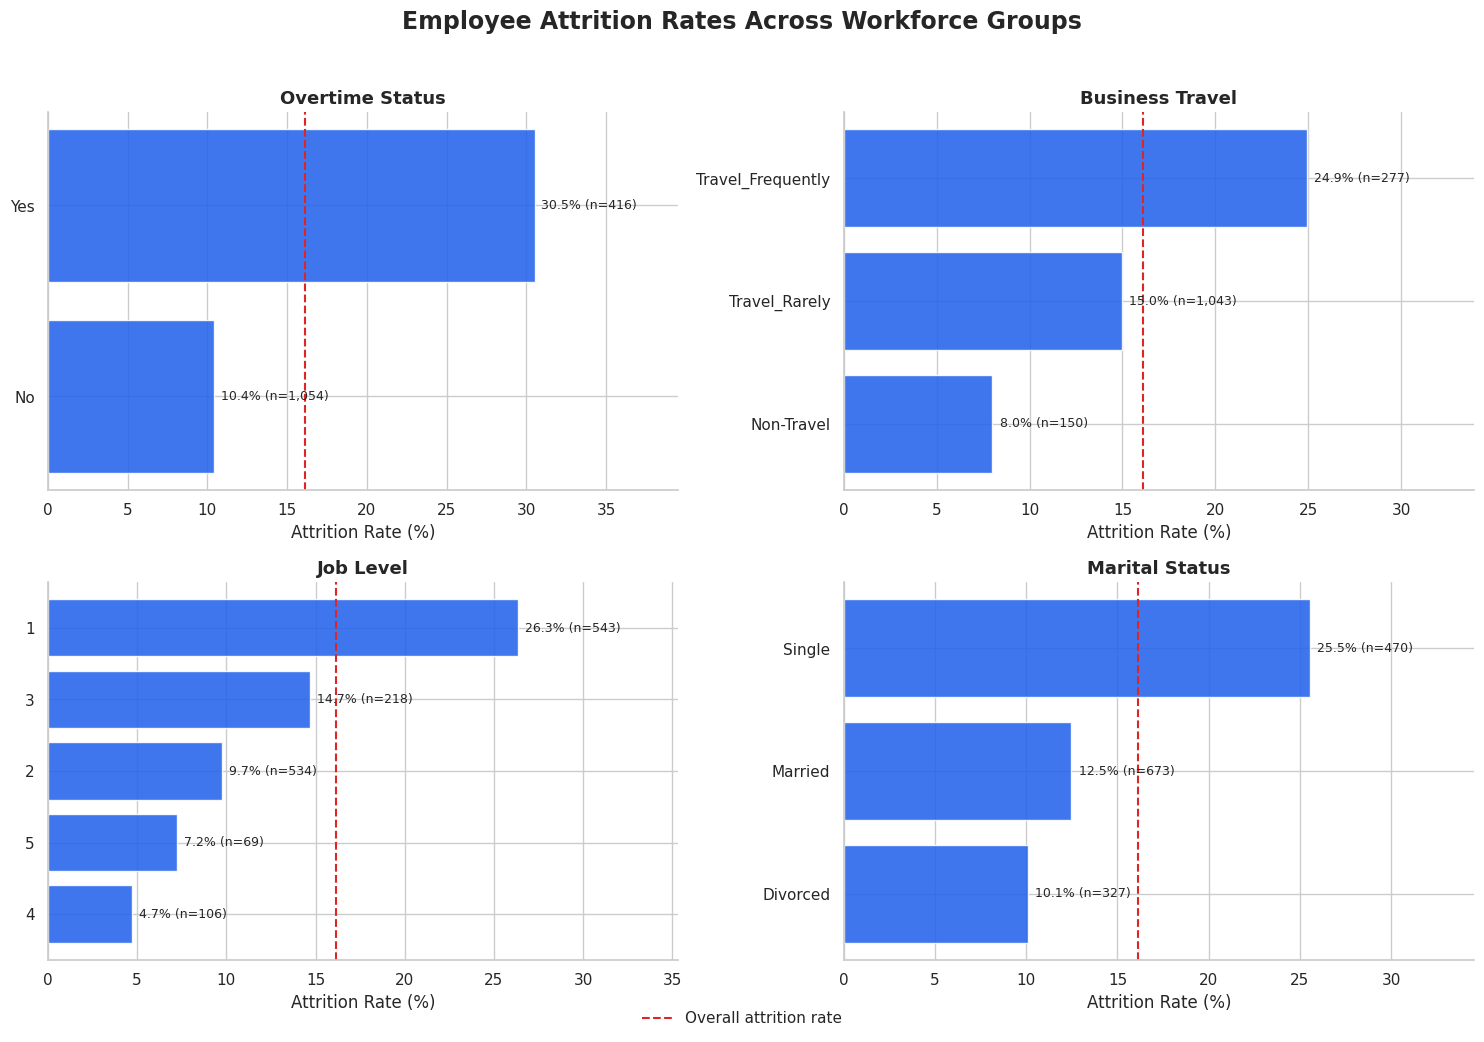

Saved: /content/employee-turnover-portfolio-visuals/attrition-rates-by-workforce-group.png


In [13]:
# Attrition rates across selected workforce groups

group_features = [
    ("OverTime", "Overtime Status"),
    ("BusinessTravel", "Business Travel"),
    ("JobLevel", "Job Level"),
    ("MaritalStatus", "Marital Status")
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

overall_attrition_rate = raw_df["AttritionFlag"].mean() * 100

for ax, (feature, display_name) in zip(axes, group_features):

    group_summary = (
        raw_df.groupby(feature, observed=False)["AttritionFlag"]
        .agg(["mean", "count"])
        .reset_index()
    )

    group_summary["attrition_rate"] = (
        group_summary["mean"] * 100
    )

    group_summary[feature] = (
        group_summary[feature]
        .astype(str)
    )

    group_summary = group_summary.sort_values(
        "attrition_rate",
        ascending=True
    )

    bars = ax.barh(
        group_summary[feature],
        group_summary["attrition_rate"],
        color="#2563EB",
        alpha=0.88
    )

    for bar, rate, count in zip(
        bars,
        group_summary["attrition_rate"],
        group_summary["count"]
    ):
        ax.text(
            rate + 0.4,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.1f}% (n={count:,})",
            va="center",
            fontsize=9
        )

    ax.axvline(
        overall_attrition_rate,
        color="#DC2626",
        linestyle="--",
        linewidth=1.5,
        label="Overall attrition rate"
    )

    ax.set_title(
        display_name,
        fontsize=13,
        fontweight="bold"
    )

    ax.set_xlabel("Attrition Rate (%)")
    ax.set_ylabel("")
    ax.set_xlim(
        0,
        max(
            group_summary["attrition_rate"].max() + 9,
            overall_attrition_rate + 5
        )
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    frameon=False
)

fig.suptitle(
    "Employee Attrition Rates Across Workforce Groups",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

chart_path = OUTPUT_DIR / "attrition-rates-by-workforce-group.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")


## 3. Responsible Modeling Design

The dataset is divided into:

- **Development set (80%)** — used for repeated cross-validation, model selection, calibration, and threshold analysis.
- **Held-out test set (20%)** — reserved for the final unbiased evaluation.

The split is stratified to preserve the attrition rate.

`Age`, `Gender`, and `MaritalStatus` are excluded from model training because they represent sensitive or potentially protected personal characteristics. They are retained separately for subgroup performance assessment.

Removing these variables does not by itself guarantee fairness, because other predictors may act as proxies. It is one component of a broader responsible-modeling approach.


In [14]:
from sklearn.model_selection import train_test_split

sensitive_features = [
    "Age",
    "Gender",
    "MaritalStatus"
]

X = model_df.drop(
    columns=[TARGET, *sensitive_features]
).copy()

y = model_df[TARGET].copy()

# Retain sensitive characteristics only for later subgroup auditing
subgroup_data = raw_df[sensitive_features].copy()

categorical_features = (
    X.select_dtypes(include=["object", "category"])
    .columns
    .tolist()
)

numeric_features = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

development_indices, test_indices = train_test_split(
    X.index,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_development = X.loc[development_indices].copy()
X_test = X.loc[test_indices].copy()

y_development = y.loc[development_indices].copy()
y_test = y.loc[test_indices].copy()

subgroups_development = subgroup_data.loc[
    development_indices
].copy()

subgroups_test = subgroup_data.loc[
    test_indices
].copy()

split_summary = pd.DataFrame({
    "Dataset": [
        "Full dataset",
        "Development set",
        "Held-out test set"
    ],
    "Rows": [
        len(y),
        len(y_development),
        len(y_test)
    ],
    "Attrition cases": [
        int(y.sum()),
        int(y_development.sum()),
        int(y_test.sum())
    ],
    "Attrition rate": [
        y.mean(),
        y_development.mean(),
        y_test.mean()
    ]
})

split_summary["Attrition rate"] = (
    split_summary["Attrition rate"] * 100
).map(lambda value: f"{value:.1f}%")

print("=" * 75)
print("RESPONSIBLE STRATIFIED DATA SPLIT")
print("=" * 75)

display(split_summary)

print(f"Modeling predictors: {X.shape[1]}")
print(f"Numeric predictors: {len(numeric_features)}")
print(f"Categorical predictors: {len(categorical_features)}")
print(
    "Excluded sensitive predictors:",
    ", ".join(sensitive_features)
)

assert set(development_indices).isdisjoint(set(test_indices))
assert len(X_development) + len(X_test) == len(X)

print("\nHeld-out test set created successfully.")

RESPONSIBLE STRATIFIED DATA SPLIT


,Dataset,Rows,Attrition cases,Attrition rate
0,Full dataset,1470,237,16.1%
1,Development set,1176,190,16.2%
2,Held-out test set,294,47,16.0%


Modeling predictors: 27
Numeric predictors: 22
Categorical predictors: 5
Excluded sensitive predictors: Age, Gender, MaritalStatus

Held-out test set created successfully.


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

models = {
    "Dummy Baseline": DummyClassifier(
        strategy="prior"
    ),

    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    "LASSO Logistic Regression": LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=2,
        random_state=RANDOM_STATE
    ),

    "RBF Support Vector Machine": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        probability=True,
        random_state=RANDOM_STATE
    )
}

model_pipelines = {
    model_name: Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )
    for model_name, model in models.items()
}

print("=" * 75)
print("MODELING PIPELINES CREATED")
print("=" * 75)

print(f"Models prepared: {len(model_pipelines)}")

for model_name in model_pipelines:
    print(f"- {model_name}")

MODELING PIPELINES CREATED
Models prepared: 6
- Dummy Baseline
- Logistic Regression
- LASSO Logistic Regression
- Random Forest
- Gradient Boosting
- RBF Support Vector Machine


## 4. Repeated Cross-Validation Model Comparison

Six classification approaches are evaluated using repeated stratified five-fold cross-validation.

The dummy classifier provides a no-skill benchmark. **PR-AUC** is the primary ranking metric because it focuses on performance for the minority attrition class. ROC-AUC, recall, precision, F1, balanced accuracy, and Brier score provide complementary evidence.

The held-out test set remains untouched during this comparison.


In [16]:
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score
)

repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "brier": "neg_brier_score"
}

cv_rows = []

for model_name, pipeline in model_pipelines.items():

    print(f"Evaluating {model_name}...")

    scores = cross_validate(
        estimator=pipeline,
        X=X_development,
        y=y_development,
        cv=repeated_cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
        error_score="raise"
    )

    cv_rows.append({
        "Model": model_name,
        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy SD": scores["test_accuracy"].std(),
        "Balanced Accuracy Mean":
            scores["test_balanced_accuracy"].mean(),
        "Precision Mean": scores["test_precision"].mean(),
        "Recall Mean": scores["test_recall"].mean(),
        "F1 Mean": scores["test_f1"].mean(),
        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "PR-AUC Mean": scores["test_pr_auc"].mean(),
        "Brier Score Mean": -scores["test_brier"].mean()
    })

cv_results = (
    pd.DataFrame(cv_rows)
    .sort_values(
        "PR-AUC Mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 95)
print("REPEATED CROSS-VALIDATION RESULTS")
print("=" * 95)

display(
    cv_results.style.format({
        column: "{:.3f}"
        for column in cv_results.columns
        if column != "Model"
    })
)

best_cv_model_name = cv_results.loc[0, "Model"]

print(
    "\nHighest development PR-AUC:",
    best_cv_model_name
)

Evaluating Dummy Baseline...
Evaluating Logistic Regression...
Evaluating LASSO Logistic Regression...
Evaluating Random Forest...
Evaluating Gradient Boosting...
Evaluating RBF Support Vector Machine...

REPEATED CROSS-VALIDATION RESULTS


,Model,Accuracy Mean,Accuracy SD,Balanced Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean,PR-AUC Mean,Brier Score Mean
0,LASSO Logistic Regression,0.754,0.021,0.746,0.370,0.735,0.491,0.822,0.596,0.162
1,Logistic Regression,0.756,0.022,0.750,0.374,0.740,0.495,0.822,0.594,0.162
2,Gradient Boosting,0.867,0.008,0.625,0.767,0.268,0.393,0.811,0.580,0.100
3,RBF Support Vector Machine,0.817,0.014,0.729,0.450,0.598,0.512,0.796,0.539,0.105
4,Random Forest,0.859,0.018,0.644,0.636,0.326,0.427,0.790,0.527,0.118
5,Dummy Baseline,0.838,0.000,0.500,0.000,0.000,0.000,0.500,0.162,0.135



Highest development PR-AUC: LASSO Logistic Regression


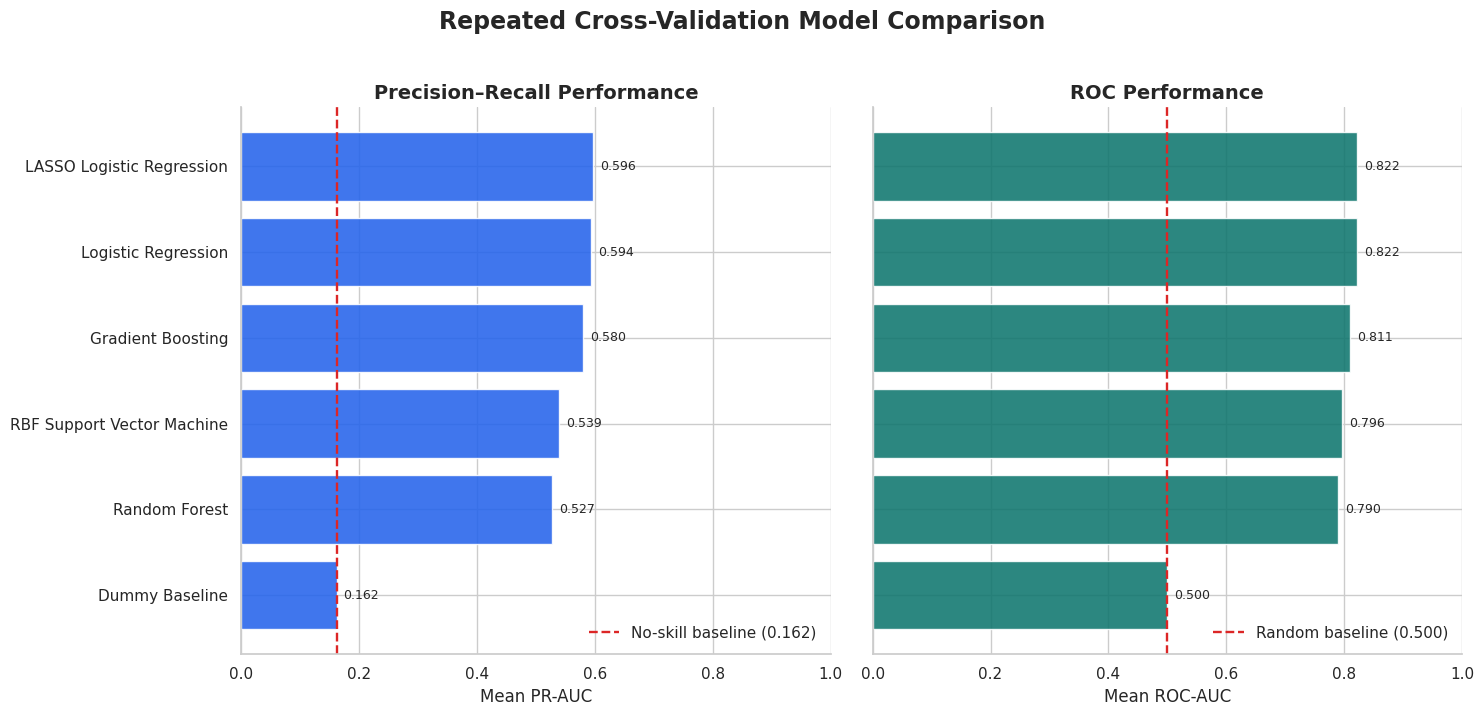

Selected model: LASSO Logistic Regression
Saved: /content/employee-turnover-portfolio-visuals/model-comparison.png


In [17]:
# Cross-validation model-comparison visual

comparison_plot = (
    cv_results
    .sort_values("PR-AUC Mean", ascending=True)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 7),
    sharey=True
)

# PR-AUC comparison
axes[0].barh(
    comparison_plot["Model"],
    comparison_plot["PR-AUC Mean"],
    color="#2563EB",
    alpha=0.88
)

axes[0].axvline(
    y_development.mean(),
    color="#DC2626",
    linestyle="--",
    linewidth=1.7,
    label=f"No-skill baseline ({y_development.mean():.3f})"
)

for index, value in enumerate(
    comparison_plot["PR-AUC Mean"]
):
    axes[0].text(
        value + 0.012,
        index,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

axes[0].set_title(
    "Precision–Recall Performance",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Mean PR-AUC")
axes[0].set_xlim(0, 1.0)
axes[0].legend(loc="lower right", frameon=False)

# ROC-AUC comparison
axes[1].barh(
    comparison_plot["Model"],
    comparison_plot["ROC-AUC Mean"],
    color="#0F766E",
    alpha=0.88
)

axes[1].axvline(
    0.50,
    color="#DC2626",
    linestyle="--",
    linewidth=1.7,
    label="Random baseline (0.500)"
)

for index, value in enumerate(
    comparison_plot["ROC-AUC Mean"]
):
    axes[1].text(
        value + 0.012,
        index,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

axes[1].set_title(
    "ROC Performance",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Mean ROC-AUC")
axes[1].set_xlim(0, 1.0)
axes[1].legend(loc="lower right", frameon=False)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Repeated Cross-Validation Model Comparison",
    fontsize=17,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

chart_path = OUTPUT_DIR / "model-comparison.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Selected model: {best_cv_model_name}")
print(f"Saved: {chart_path}")


## 5. Probability Calibration

The selected class-weighted LASSO model prioritizes minority-class detection, but its raw probability estimates are not automatically reliable.

Sigmoid calibration is therefore evaluated using out-of-fold development predictions. Calibration quality is assessed using the Brier score and calibration curve. Lower Brier scores indicate more accurate probability estimates.

OUT-OF-FOLD PROBABILITY CALIBRATION RESULTS


,Probability Model,Brier Score,ROC-AUC,PR-AUC
0,Uncalibrated LASSO,0.161,0.825,0.598
1,Sigmoid-Calibrated LASSO,0.099,0.824,0.598


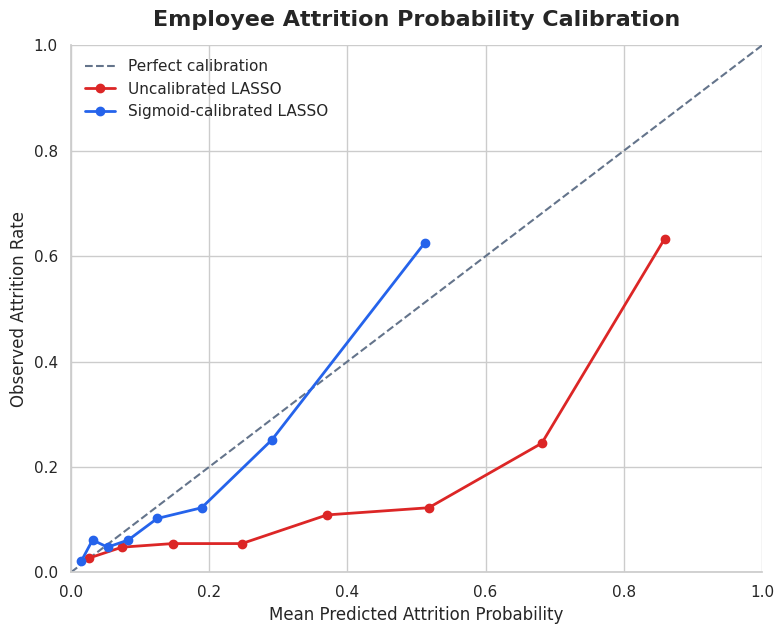

Saved: /content/employee-turnover-portfolio-visuals/probability-calibration.png


In [18]:
from sklearn.base import clone
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)
from sklearn.metrics import (
    brier_score_loss,
    average_precision_score,
    roc_auc_score
)

selected_pipeline = clone(
    model_pipelines["LASSO Logistic Regression"]
)

calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Out-of-fold probabilities from the uncalibrated model
uncalibrated_oof_probability = cross_val_predict(
    selected_pipeline,
    X_development,
    y_development,
    cv=calibration_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Sigmoid-calibrated version of the selected model
calibrated_model = CalibratedClassifierCV(
    estimator=clone(selected_pipeline),
    method="sigmoid",
    cv=5
)

# Out-of-fold probabilities from the calibrated model
calibrated_oof_probability = cross_val_predict(
    calibrated_model,
    X_development,
    y_development,
    cv=calibration_cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

calibration_results = pd.DataFrame({
    "Probability Model": [
        "Uncalibrated LASSO",
        "Sigmoid-Calibrated LASSO"
    ],
    "Brier Score": [
        brier_score_loss(
            y_development,
            uncalibrated_oof_probability
        ),
        brier_score_loss(
            y_development,
            calibrated_oof_probability
        )
    ],
    "ROC-AUC": [
        roc_auc_score(
            y_development,
            uncalibrated_oof_probability
        ),
        roc_auc_score(
            y_development,
            calibrated_oof_probability
        )
    ],
    "PR-AUC": [
        average_precision_score(
            y_development,
            uncalibrated_oof_probability
        ),
        average_precision_score(
            y_development,
            calibrated_oof_probability
        )
    ]
})

print("=" * 80)
print("OUT-OF-FOLD PROBABILITY CALIBRATION RESULTS")
print("=" * 80)

display(
    calibration_results.style.format({
        "Brier Score": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "PR-AUC": "{:.3f}"
    })
)

# Calibration-curve coordinates
uncalibrated_fraction, uncalibrated_mean = calibration_curve(
    y_development,
    uncalibrated_oof_probability,
    n_bins=8,
    strategy="quantile"
)

calibrated_fraction, calibrated_mean = calibration_curve(
    y_development,
    calibrated_oof_probability,
    n_bins=8,
    strategy="quantile"
)

fig, ax = plt.subplots(figsize=(8, 6.5))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#64748B",
    label="Perfect calibration"
)

ax.plot(
    uncalibrated_mean,
    uncalibrated_fraction,
    marker="o",
    linewidth=2,
    color="#DC2626",
    label="Uncalibrated LASSO"
)

ax.plot(
    calibrated_mean,
    calibrated_fraction,
    marker="o",
    linewidth=2,
    color="#2563EB",
    label="Sigmoid-calibrated LASSO"
)

ax.set_title(
    "Employee Attrition Probability Calibration",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Mean Predicted Attrition Probability")
ax.set_ylabel("Observed Attrition Rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

chart_path = OUTPUT_DIR / "probability-calibration.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")

## 6. Cost-Sensitive Review Threshold

A model probability is not an employment decision. In this demonstration, the threshold only determines which cases could be prioritized for voluntary retention research or supportive outreach.

For the scenario analysis:

- a **false negative** represents an attrition case not prioritized for review;
- a **false positive** represents unnecessary review or outreach;
- a false negative is assigned five times the relative cost of a false positive.

These costs are illustrative assumptions, not measured organizational costs. The threshold is selected exclusively from out-of-fold development predictions.

COST-SENSITIVE DEVELOPMENT THRESHOLD SELECTION
Probability model: Sigmoid-Calibrated LASSO Logistic Regression
False-positive relative cost: 1
False-negative relative cost: 5
Selected development threshold: 0.26


,Decision Rule,Threshold,Precision,Recall,F1,False Positives,False Negatives,Total Relative Cost
0,Default Threshold,0.50,0.769,0.263,0.392,15,140,715
1,Minimum-Cost Threshold,0.26,0.481,0.658,0.556,135,65,460


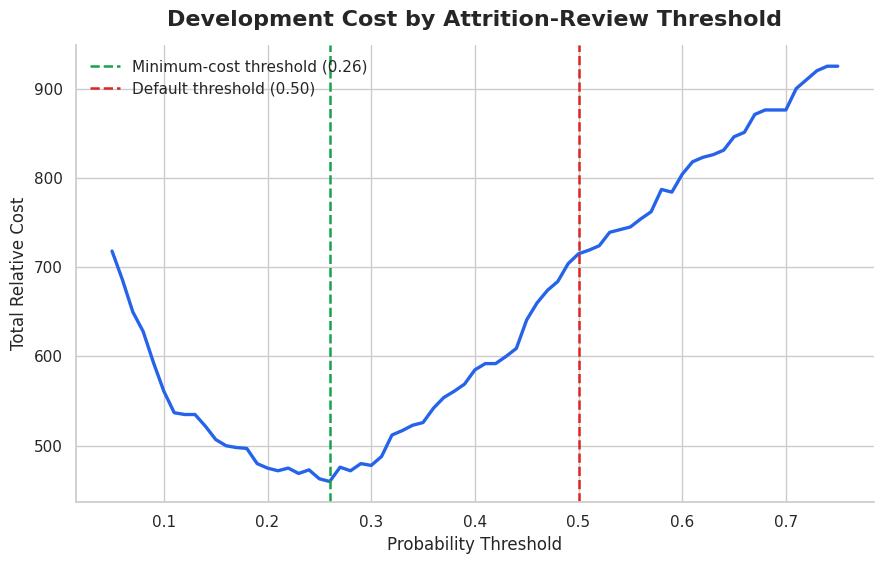

Saved: /content/employee-turnover-portfolio-visuals/threshold-cost-analysis.png


In [19]:
from sklearn.metrics import confusion_matrix

FALSE_POSITIVE_COST = 1
FALSE_NEGATIVE_COST = 5

threshold_grid = np.arange(
    0.05,
    0.76,
    0.01
)

threshold_rows = []

for threshold in threshold_grid:

    predictions = (
        calibrated_oof_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_development,
        predictions,
        labels=[0, 1]
    ).ravel()

    total_relative_cost = (
        fp * FALSE_POSITIVE_COST
        + fn * FALSE_NEGATIVE_COST
    )

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_development,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_development,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_development,
            predictions,
            zero_division=0
        ),
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "True Negatives": tn,
        "Total Relative Cost": total_relative_cost
    })

threshold_results = pd.DataFrame(threshold_rows)

selected_threshold_row = (
    threshold_results
    .sort_values(
        ["Total Relative Cost", "F1"],
        ascending=[True, False]
    )
    .iloc[0]
)

selected_threshold = float(
    selected_threshold_row["Threshold"]
)

default_threshold_row = (
    threshold_results.loc[
        np.isclose(
            threshold_results["Threshold"],
            0.50
        )
    ]
    .iloc[0]
)

threshold_comparison = pd.DataFrame([
    {
        "Decision Rule": "Default Threshold",
        **default_threshold_row.to_dict()
    },
    {
        "Decision Rule": "Minimum-Cost Threshold",
        **selected_threshold_row.to_dict()
    }
])

print("=" * 80)
print("COST-SENSITIVE DEVELOPMENT THRESHOLD SELECTION")
print("=" * 80)

print(
    "Probability model: Sigmoid-Calibrated "
    "LASSO Logistic Regression"
)

print(
    f"False-positive relative cost: "
    f"{FALSE_POSITIVE_COST}"
)

print(
    f"False-negative relative cost: "
    f"{FALSE_NEGATIVE_COST}"
)

print(
    f"Selected development threshold: "
    f"{selected_threshold:.2f}"
)

display(
    threshold_comparison[
        [
            "Decision Rule",
            "Threshold",
            "Precision",
            "Recall",
            "F1",
            "False Positives",
            "False Negatives",
            "Total Relative Cost"
        ]
    ].style.format({
        "Threshold": "{:.2f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1": "{:.3f}",
        "False Positives": "{:.0f}",
        "False Negatives": "{:.0f}",
        "Total Relative Cost": "{:.0f}"
    })
)

fig, ax = plt.subplots(figsize=(9, 5.8))

ax.plot(
    threshold_results["Threshold"],
    threshold_results["Total Relative Cost"],
    color="#2563EB",
    linewidth=2.4
)

ax.axvline(
    selected_threshold,
    color="#16A34A",
    linestyle="--",
    linewidth=1.8,
    label=(
        "Minimum-cost threshold "
        f"({selected_threshold:.2f})"
    )
)

ax.axvline(
    0.50,
    color="#DC2626",
    linestyle="--",
    linewidth=1.8,
    label="Default threshold (0.50)"
)

ax.set_title(
    "Development Cost by Attrition-Review Threshold",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Probability Threshold")
ax.set_ylabel("Total Relative Cost")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

chart_path = OUTPUT_DIR / "threshold-cost-analysis.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")

## 7. Final Held-Out Test Evaluation

After completing model selection, calibration, and threshold selection using development data, the calibrated LASSO model is fitted to the full development set and evaluated once on the untouched test set.

Results are reported for both the conventional 0.50 threshold and the development-selected 0.26 threshold. The test set is not used to revise either threshold.

FINAL HELD-OUT TEST RESULTS
ROC-AUC: 0.781
PR-AUC: 0.554
Brier Score: 0.104
Default-threshold cost: 177
Development-selected threshold cost: 141
Relative cost reduction: 20.3%


,Decision Rule,Threshold,Accuracy,Balanced Accuracy,Precision,Recall,Specificity,F1,False Positives,False Negatives,Total Relative Cost
0,Default Threshold,0.50,0.874,0.624,0.857,0.255,0.992,0.393,2,35,177
1,Development-Selected Threshold,0.26,0.820,0.703,0.446,0.532,0.874,0.485,31,22,141


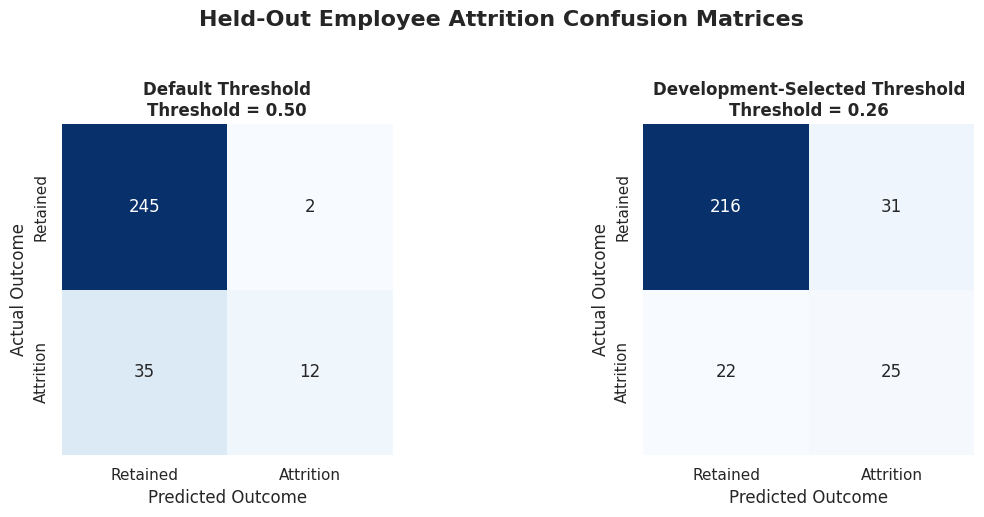

Saved: /content/employee-turnover-portfolio-visuals/held-out-confusion-matrices.png


In [20]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# Fit the final calibrated model using development data only
final_model = clone(calibrated_model)

final_model.fit(
    X_development,
    y_development
)

# Open the held-out test set once
test_probability = final_model.predict_proba(
    X_test
)[:, 1]

test_roc_auc = roc_auc_score(
    y_test,
    test_probability
)

test_pr_auc = average_precision_score(
    y_test,
    test_probability
)

test_brier = brier_score_loss(
    y_test,
    test_probability
)

def evaluate_threshold(
    actual,
    probability,
    threshold,
    rule_name
):
    predicted = (
        probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        actual,
        predicted,
        labels=[0, 1]
    ).ravel()

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else np.nan
    )

    relative_cost = (
        fp * FALSE_POSITIVE_COST
        + fn * FALSE_NEGATIVE_COST
    )

    return {
        "Decision Rule": rule_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            actual,
            predicted
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            actual,
            predicted
        ),
        "Precision": precision_score(
            actual,
            predicted,
            zero_division=0
        ),
        "Recall": recall_score(
            actual,
            predicted,
            zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            actual,
            predicted,
            zero_division=0
        ),
        "False Positives": fp,
        "False Negatives": fn,
        "True Positives": tp,
        "True Negatives": tn,
        "Total Relative Cost": relative_cost
    }

test_results = pd.DataFrame([
    evaluate_threshold(
        y_test,
        test_probability,
        0.50,
        "Default Threshold"
    ),
    evaluate_threshold(
        y_test,
        test_probability,
        selected_threshold,
        "Development-Selected Threshold"
    )
])

default_test_cost = int(
    test_results.loc[
        test_results["Decision Rule"]
        == "Default Threshold",
        "Total Relative Cost"
    ].iloc[0]
)

selected_test_cost = int(
    test_results.loc[
        test_results["Decision Rule"]
        == "Development-Selected Threshold",
        "Total Relative Cost"
    ].iloc[0]
)

relative_cost_change = (
    (default_test_cost - selected_test_cost)
    / default_test_cost
    * 100
)

print("=" * 90)
print("FINAL HELD-OUT TEST RESULTS")
print("=" * 90)

print(f"ROC-AUC: {test_roc_auc:.3f}")
print(f"PR-AUC: {test_pr_auc:.3f}")
print(f"Brier Score: {test_brier:.3f}")
print(f"Default-threshold cost: {default_test_cost}")
print(
    "Development-selected threshold cost:",
    selected_test_cost
)
print(
    f"Relative cost reduction: "
    f"{relative_cost_change:.1f}%"
)

display(
    test_results[
        [
            "Decision Rule",
            "Threshold",
            "Accuracy",
            "Balanced Accuracy",
            "Precision",
            "Recall",
            "Specificity",
            "F1",
            "False Positives",
            "False Negatives",
            "Total Relative Cost"
        ]
    ].style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.3f}",
        "Balanced Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "Specificity": "{:.3f}",
        "F1": "{:.3f}",
        "False Positives": "{:.0f}",
        "False Negatives": "{:.0f}",
        "Total Relative Cost": "{:.0f}"
    })
)

# Confusion-matrix visual
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

for ax, result in zip(
    axes,
    test_results.to_dict("records")
):
    threshold = result["Threshold"]

    predictions = (
        test_probability >= threshold
    ).astype(int)

    matrix = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        square=True,
        ax=ax,
        xticklabels=["Retained", "Attrition"],
        yticklabels=["Retained", "Attrition"]
    )

    ax.set_title(
        f"{result['Decision Rule']}\n"
        f"Threshold = {threshold:.2f}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted Outcome")
    ax.set_ylabel("Actual Outcome")

fig.suptitle(
    "Held-Out Employee Attrition Confusion Matrices",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

chart_path = OUTPUT_DIR / "held-out-confusion-matrices.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")

## 8. Uncertainty Assessment

Because the held-out test set contains only 294 employees and 47 attrition cases, point estimates may be unstable.

Bootstrap confidence intervals are calculated from 2,000 resamples of the held-out predictions. These intervals quantify sampling uncertainty; they do not address dataset realism, organizational drift, or external validity.

In [21]:
# Bootstrap confidence intervals for held-out performance

BOOTSTRAP_SAMPLES = 2000
bootstrap_rng = np.random.default_rng(RANDOM_STATE)

actual_array = y_test.to_numpy()
probability_array = np.asarray(test_probability)

selected_predictions = (
    probability_array >= selected_threshold
).astype(int)

bootstrap_rows = []

for _ in range(BOOTSTRAP_SAMPLES):

    sample_indices = bootstrap_rng.integers(
        0,
        len(actual_array),
        len(actual_array)
    )

    sampled_actual = actual_array[sample_indices]
    sampled_probability = probability_array[sample_indices]

    # ROC-AUC and PR-AUC require both classes
    if np.unique(sampled_actual).size < 2:
        continue

    sampled_prediction = (
        sampled_probability >= selected_threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        sampled_actual,
        sampled_prediction,
        labels=[0, 1]
    ).ravel()

    relative_cost = (
        fp * FALSE_POSITIVE_COST
        + fn * FALSE_NEGATIVE_COST
    )

    bootstrap_rows.append({
        "Accuracy": accuracy_score(
            sampled_actual,
            sampled_prediction
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            sampled_actual,
            sampled_prediction
        ),
        "Precision": precision_score(
            sampled_actual,
            sampled_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            sampled_actual,
            sampled_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            sampled_actual,
            sampled_prediction,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            sampled_actual,
            sampled_probability
        ),
        "PR-AUC": average_precision_score(
            sampled_actual,
            sampled_probability
        ),
        "Brier Score": brier_score_loss(
            sampled_actual,
            sampled_probability
        ),
        "Relative Cost": relative_cost
    })

bootstrap_results = pd.DataFrame(bootstrap_rows)

point_estimates = {
    "Accuracy": accuracy_score(
        actual_array,
        selected_predictions
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        actual_array,
        selected_predictions
    ),
    "Precision": precision_score(
        actual_array,
        selected_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        actual_array,
        selected_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        actual_array,
        selected_predictions,
        zero_division=0
    ),
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc,
    "Brier Score": test_brier,
    "Relative Cost": selected_test_cost
}

confidence_rows = []

for metric, point_estimate in point_estimates.items():

    lower_bound = bootstrap_results[
        metric
    ].quantile(0.025)

    upper_bound = bootstrap_results[
        metric
    ].quantile(0.975)

    confidence_rows.append({
        "Metric": metric,
        "Point Estimate": point_estimate,
        "95% CI Lower": lower_bound,
        "95% CI Upper": upper_bound
    })

confidence_intervals = pd.DataFrame(confidence_rows)

print("=" * 85)
print("HELD-OUT BOOTSTRAP CONFIDENCE INTERVALS")
print("=" * 85)

print(
    f"Successful bootstrap samples: "
    f"{len(bootstrap_results):,}"
)

display(
    confidence_intervals.style.format({
        "Point Estimate": "{:.3f}",
        "95% CI Lower": "{:.3f}",
        "95% CI Upper": "{:.3f}"
    })
)

HELD-OUT BOOTSTRAP CONFIDENCE INTERVALS
Successful bootstrap samples: 2,000


,Metric,Point Estimate,95% CI Lower,95% CI Upper
0,Accuracy,0.820,0.776,0.861
1,Balanced Accuracy,0.703,0.628,0.779
2,Precision,0.446,0.310,0.582
3,Recall,0.532,0.386,0.675
4,F1,0.485,0.360,0.598
5,ROC-AUC,0.781,0.696,0.855
6,PR-AUC,0.554,0.418,0.680
7,Brier Score,0.104,0.078,0.129
8,Relative Cost,141.000,97.000,188.000


## 9. Model Interpretation

Permutation importance measures how much held-out PR-AUC decreases when each predictor is randomly disrupted.

A larger positive value indicates that the model relies more heavily on that feature for ranking attrition cases. Negative or near-zero values indicate that the feature did not provide stable held-out value.

Permutation importance describes predictive reliance, not causation or the direction of an effect.

PERMUTATION IMPORTANCE USING HELD-OUT PR-AUC


,Feature,Mean Importance,Importance SD
0,OverTime,0.2241,0.0277
1,TotalWorkingYears,0.0971,0.0379
2,JobSatisfaction,0.0667,0.0197
3,NumCompaniesWorked,0.0530,0.0136
4,JobRole,0.0478,0.0298
5,YearsSinceLastPromotion,0.0412,0.0256
6,EnvironmentSatisfaction,0.0364,0.0253
7,StockOptionLevel,0.0261,0.0146
8,Department,0.0247,0.0281
9,JobInvolvement,0.0227,0.0125


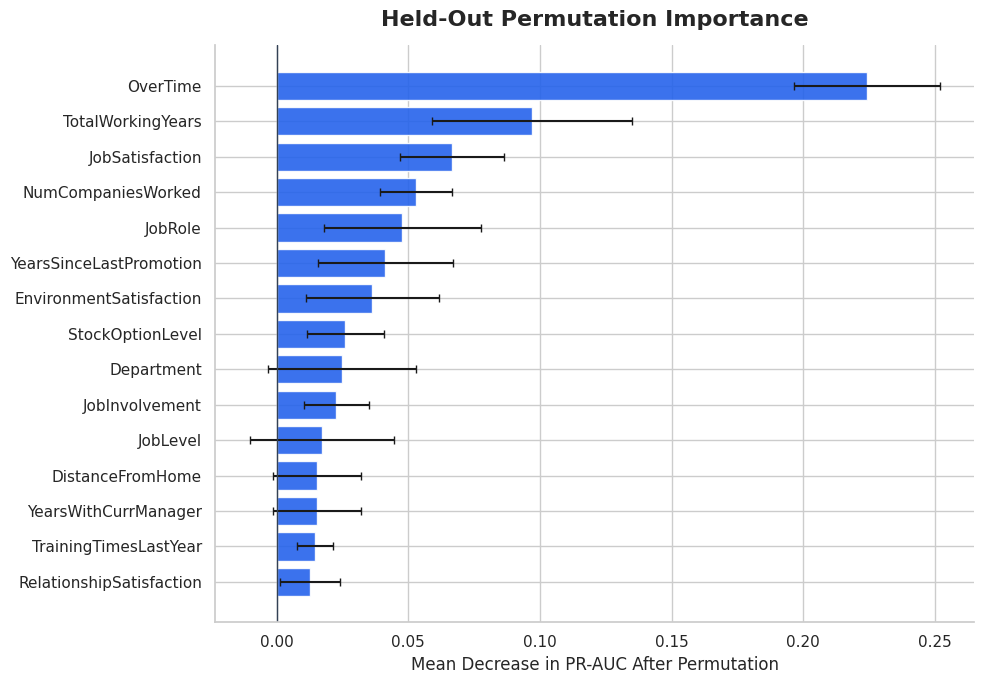

Saved: /content/employee-turnover-portfolio-visuals/permutation-importance.png


In [22]:
from sklearn.inspection import permutation_importance

permutation_results = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    scoring="average_precision",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Importance":
        permutation_results.importances_mean,
    "Importance SD":
        permutation_results.importances_std
}).sort_values(
    "Mean Importance",
    ascending=False
).reset_index(drop=True)

print("=" * 80)
print("PERMUTATION IMPORTANCE USING HELD-OUT PR-AUC")
print("=" * 80)

display(
    importance_df.style.format({
        "Mean Importance": "{:.4f}",
        "Importance SD": "{:.4f}"
    })
)

top_importance = (
    importance_df
    .head(15)
    .sort_values(
        "Mean Importance",
        ascending=True
    )
)

fig, ax = plt.subplots(figsize=(10, 7))

colors = [
    "#2563EB" if value > 0 else "#94A3B8"
    for value in top_importance["Mean Importance"]
]

ax.barh(
    top_importance["Feature"],
    top_importance["Mean Importance"],
    xerr=top_importance["Importance SD"],
    color=colors,
    alpha=0.9,
    capsize=3
)

ax.axvline(
    0,
    color="#334155",
    linewidth=1
)

ax.set_title(
    "Held-Out Permutation Importance",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    "Mean Decrease in PR-AUC After Permutation"
)

ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

chart_path = OUTPUT_DIR / "permutation-importance.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")

## 10. Subgroup Performance Audit

Age, gender, and marital status were excluded from model training. They are used only after prediction to assess whether performance differs across available groups.

The audit compares sample size, attrition prevalence, selection rate, precision, recall, and false-positive rate. Because some subgroups are small, differences should be treated as screening evidence requiring further investigation—not proof of fairness or discrimination.

HELD-OUT SUBGROUP PERFORMANCE AUDIT


,Attribute,Group,Employees,Attrition Cases,Attrition Prevalence,Review Selection Rate,Precision,Recall,False Positive Rate
0,Gender,Female,116,16,13.8%,21.6%,0.440,0.688,0.140
1,Gender,Male,178,31,17.4%,17.4%,0.452,0.452,0.116
2,MaritalStatus,Divorced,64,4,6.2%,7.8%,0.400,0.500,0.050
3,MaritalStatus,Married,133,18,13.5%,12.8%,0.471,0.444,0.078
4,MaritalStatus,Single,97,25,25.8%,35.1%,0.441,0.600,0.264
5,Age Group,Under 30,68,17,25.0%,32.4%,0.500,0.647,0.216
6,Age Group,30–39,125,14,11.2%,17.6%,0.409,0.643,0.117
7,Age Group,40–49,67,8,11.9%,11.9%,0.375,0.375,0.085
8,Age Group,50+,34,8,23.5%,11.8%,0.500,0.250,0.077


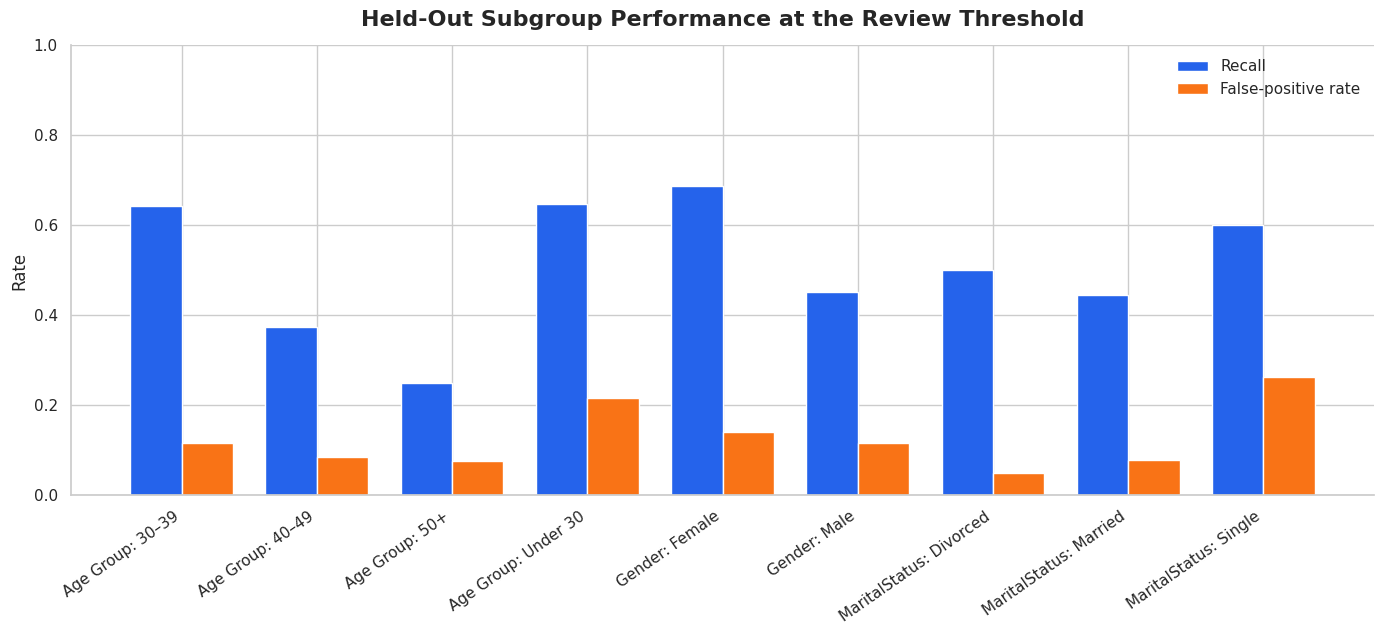

Saved: /content/employee-turnover-portfolio-visuals/subgroup-performance-audit.png


In [23]:
# Subgroup performance audit at the locked 0.26 threshold

subgroup_audit_df = subgroups_test.copy()

subgroup_audit_df["Actual Attrition"] = (
    y_test.to_numpy()
)

subgroup_audit_df["Predicted Probability"] = (
    test_probability
)

subgroup_audit_df["Prioritized for Review"] = (
    test_probability >= selected_threshold
).astype(int)

subgroup_audit_df["Age Group"] = pd.cut(
    subgroup_audit_df["Age"],
    bins=[0, 29, 39, 49, np.inf],
    labels=[
        "Under 30",
        "30–39",
        "40–49",
        "50+"
    ],
    right=True
)

audit_attributes = [
    "Gender",
    "MaritalStatus",
    "Age Group"
]

subgroup_rows = []

for attribute in audit_attributes:

    for group_value, group_df in subgroup_audit_df.groupby(
        attribute,
        observed=False
    ):

        actual = group_df["Actual Attrition"].to_numpy()

        predicted = group_df[
            "Prioritized for Review"
        ].to_numpy()

        tn, fp, fn, tp = confusion_matrix(
            actual,
            predicted,
            labels=[0, 1]
        ).ravel()

        subgroup_rows.append({
            "Attribute": attribute,
            "Group": str(group_value),
            "Employees": len(group_df),
            "Attrition Cases": int(actual.sum()),
            "Attrition Prevalence": actual.mean(),
            "Review Selection Rate": predicted.mean(),
            "Precision": (
                tp / (tp + fp)
                if (tp + fp) > 0
                else np.nan
            ),
            "Recall": (
                tp / (tp + fn)
                if (tp + fn) > 0
                else np.nan
            ),
            "False Positive Rate": (
                fp / (fp + tn)
                if (fp + tn) > 0
                else np.nan
            )
        })

subgroup_results = pd.DataFrame(subgroup_rows)

print("=" * 90)
print("HELD-OUT SUBGROUP PERFORMANCE AUDIT")
print("=" * 90)

display(
    subgroup_results.style.format({
        "Attrition Prevalence": "{:.1%}",
        "Review Selection Rate": "{:.1%}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "False Positive Rate": "{:.3f}"
    })
)

# Visualize recall and false-positive rates
audit_plot = subgroup_results.copy()

audit_plot["Group Label"] = (
    audit_plot["Attribute"]
    + ": "
    + audit_plot["Group"]
)

audit_plot = audit_plot.sort_values(
    ["Attribute", "Group"]
)

x_positions = np.arange(len(audit_plot))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(14, 6.5))

ax.bar(
    x_positions - bar_width / 2,
    audit_plot["Recall"],
    width=bar_width,
    color="#2563EB",
    label="Recall"
)

ax.bar(
    x_positions + bar_width / 2,
    audit_plot["False Positive Rate"],
    width=bar_width,
    color="#F97316",
    label="False-positive rate"
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    audit_plot["Group Label"],
    rotation=35,
    ha="right"
)

ax.set_ylim(0, 1)

ax.set_title(
    "Held-Out Subgroup Performance at the Review Threshold",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_ylabel("Rate")
ax.set_xlabel("")
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

chart_path = OUTPUT_DIR / "subgroup-performance-audit.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")

## 11. Direction of Predictive Associations

Standardized LASSO coefficients are examined to understand the direction of the model’s associations.

Positive coefficients are associated with higher predicted attrition scores, while negative coefficients are associated with lower scores. Categorical coefficients are interpreted relative to the category omitted during one-hot encoding.

These coefficients are predictive associations—not causal effects or recommendations for individual employment action.

LASSO COEFFICIENT INTERPRETATION


,Feature,Coefficient,Absolute Coefficient,Direction
0,OverTime_Yes,1.573,1.573,Higher attrition score
1,JobRole_Laboratory Technician,1.569,1.569,Higher attrition score
2,BusinessTravel_Travel_Frequently,1.456,1.456,Higher attrition score
3,JobRole_Sales Representative,1.233,1.233,Higher attrition score
4,JobRole_Research Director,-1.224,1.224,Lower attrition score
5,EducationField_Other,-1.088,1.088,Lower attrition score
6,TotalWorkingYears,-0.858,0.858,Lower attrition score
7,Department_Research & Development,-0.845,0.845,Lower attrition score
8,BusinessTravel_Travel_Rarely,0.769,0.769,Higher attrition score
9,JobLevel,0.511,0.511,Higher attrition score


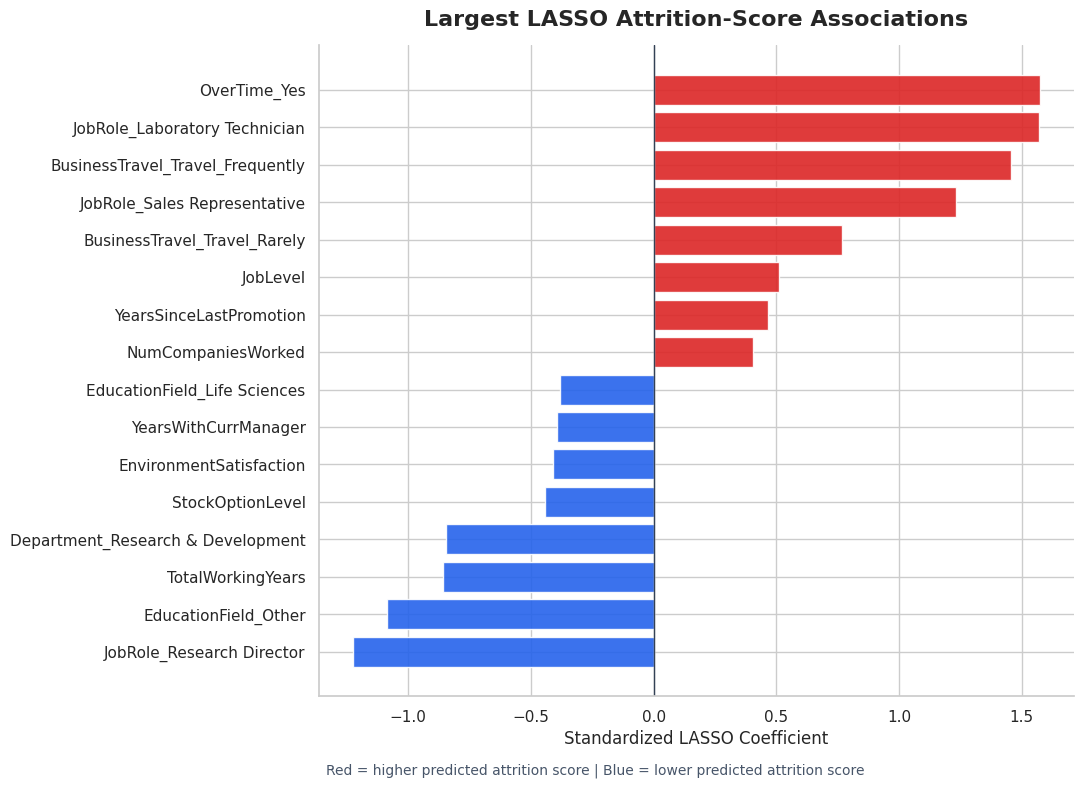

Saved: /content/employee-turnover-portfolio-visuals/lasso-coefficient-direction.png


In [24]:
# Fit an interpretable uncalibrated LASSO for coefficient inspection

interpretation_model = clone(selected_pipeline)

interpretation_model.fit(
    X_development,
    y_development
)

fitted_preprocessor = interpretation_model.named_steps[
    "preprocessor"
]

fitted_lasso = interpretation_model.named_steps[
    "model"
]

encoded_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

clean_feature_names = [
    name
    .replace("numeric__", "")
    .replace("categorical__", "")
    for name in encoded_feature_names
]

coefficient_df = pd.DataFrame({
    "Feature": clean_feature_names,
    "Coefficient": fitted_lasso.coef_[0]
})

coefficient_df["Absolute Coefficient"] = (
    coefficient_df["Coefficient"].abs()
)

coefficient_df["Direction"] = np.where(
    coefficient_df["Coefficient"] > 0,
    "Higher attrition score",
    np.where(
        coefficient_df["Coefficient"] < 0,
        "Lower attrition score",
        "Removed by LASSO"
    )
)

coefficient_df = coefficient_df.sort_values(
    "Absolute Coefficient",
    ascending=False
).reset_index(drop=True)

print("=" * 85)
print("LASSO COEFFICIENT INTERPRETATION")
print("=" * 85)

display(
    coefficient_df.head(20).style.format({
        "Coefficient": "{:.3f}",
        "Absolute Coefficient": "{:.3f}"
    })
)

nonzero_coefficients = coefficient_df.loc[
    coefficient_df["Coefficient"] != 0
].copy()

largest_coefficients = (
    nonzero_coefficients
    .head(16)
    .sort_values("Coefficient")
)

colors = [
    "#DC2626" if value > 0 else "#2563EB"
    for value in largest_coefficients["Coefficient"]
]

fig, ax = plt.subplots(figsize=(11, 8))

ax.barh(
    largest_coefficients["Feature"],
    largest_coefficients["Coefficient"],
    color=colors,
    alpha=0.9
)

ax.axvline(
    0,
    color="#334155",
    linewidth=1
)

ax.set_title(
    "Largest LASSO Attrition-Score Associations",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel(
    "Standardized LASSO Coefficient"
)

ax.set_ylabel("")

ax.text(
    0.01,
    -0.12,
    "Red = higher predicted attrition score | "
    "Blue = lower predicted attrition score",
    transform=ax.transAxes,
    fontsize=10,
    color="#475569"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

chart_path = OUTPUT_DIR / "lasso-coefficient-direction.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {chart_path}")

## 12. Executive Findings and Recommendations

### Executive Summary

This project evaluated whether workplace and employment characteristics could support responsible employee-attrition risk analysis using the fictional IBM HR Analytics dataset.

The dataset contained **1,470 employees**, including **237 attrition cases**, producing an attrition prevalence of **16.1%**.

Age, gender, and marital status were excluded from model training. Six classification approaches were compared using repeated stratified cross-validation. LASSO logistic regression was selected because it achieved the highest development PR-AUC while retaining interpretability.

### Model-Development Results

The selected LASSO model achieved:

- **Mean development ROC-AUC:** 0.822
- **Mean development PR-AUC:** 0.596
- **Mean development recall:** 0.735
- **Mean development balanced accuracy:** 0.746

Sigmoid calibration reduced the out-of-fold Brier score from **0.161 to 0.099** while preserving ranking performance.

### Final Held-Out Results

On the untouched test set, the calibrated model achieved:

- **ROC-AUC:** 0.781
- **PR-AUC:** 0.554
- **Brier score:** 0.104

Bootstrap uncertainty intervals included:

- **ROC-AUC 95% CI:** 0.696–0.855
- **PR-AUC 95% CI:** 0.418–0.680
- **Recall 95% CI:** 0.386–0.675
- **F1 95% CI:** 0.360–0.598

The results indicate meaningful but imperfect predictive performance.

### Threshold Tradeoff

Using an illustrative cost assumption in which a missed attrition case costs five times as much as unnecessary review, the development-selected threshold was **0.26**.

On the held-out test set, the 0.26 threshold:

- increased recall from **25.5% to 53.2%**;
- increased balanced accuracy from **0.624 to 0.703**;
- increased F1 from approximately **0.393 to 0.485**;
- reduced illustrative relative cost from **177 to 141**, a **20.3% reduction**;
- reduced precision from **85.7% to 44.6%**;
- increased the number of employees prioritized for review.

This threshold should be interpreted as a voluntary-support prioritization rule—not an employment decision rule.

### Important Predictive Factors

Held-out permutation importance identified the strongest predictive contributions from:

1. Overtime
2. Total working years
3. Job satisfaction
4. Number of companies worked
5. Job role
6. Years since last promotion
7. Environment satisfaction
8. Stock-option level
9. Department
10. Job involvement

The LASSO coefficients associated overtime and frequent business travel with higher attrition scores. Greater total working experience and higher stock-option levels were associated with lower scores.

These are predictive associations and do not establish causation.

### Workforce Recommendations

1. **Investigate sustained overtime patterns**

   Review overtime levels by department, job role and manager. Use employee surveys and workload analysis to determine whether overtime reflects staffing shortages, scheduling practices or role-specific pressures.

2. **Strengthen career-development conversations**

   Years since promotion contributed to predicted attrition risk. Organizations could expand transparent career pathways, internal mobility opportunities, mentoring and voluntary development planning.

3. **Monitor employee experience at the organizational level**

   Job satisfaction, environmental satisfaction and job involvement contributed predictive information. Aggregate dashboards and anonymous surveys may help identify organizational areas requiring further investigation.

4. **Evaluate travel-intensive and role-specific conditions**

   Frequent business travel and certain job roles were associated with higher model scores. Any intervention should focus on working conditions and organizational support—not assumptions about individual employees.

5. **Use supportive, voluntary interventions**

   Employees prioritized by the model should not be labeled as intending to leave. Appropriate actions might include optional stay interviews, career resources, workload reviews and organization-wide retention programs.

6. **Monitor model performance and subgroup differences**

   The model showed meaningful recall differences across gender and age groups. A real deployment would require larger subgroup samples, fairness criteria, periodic monitoring, legal review and an appeal or feedback process.

### Subgroup Findings

At the selected threshold:

- recall was 68.8% for females and 45.2% for males;
- recall was 64.7% for employees under 30 and 64.3% for ages 30–39;
- recall fell to 37.5% for ages 40–49 and 25.0% for ages 50+;
- single employees had the highest observed false-positive rate at 26.4%.

These results do not establish discrimination, but they show that excluding sensitive attributes does not guarantee equal performance. Small subgroup counts also create substantial uncertainty.

### Limitations

- The IBM dataset is fictional and designed for analytical practice.
- The data is cross-sectional and does not establish temporal or causal relationships.
- The held-out test set contains only 47 attrition cases.
- Cost assumptions are illustrative rather than estimated from an employer.
- Subgroup metrics are unstable for groups with few attrition cases.
- Unobserved workplace, management and labor-market factors may affect attrition.
- Results may not generalize to a real organization or future workforce.
- Predictors may act as proxies for sensitive characteristics.

### Responsible-Use Conclusion

The model demonstrates how calibrated probabilities, class-sensitive evaluation, threshold analysis, uncertainty estimation and subgroup auditing can support responsible workforce analytics.

It must not be used to terminate, discipline, deny promotion to, or otherwise make adverse decisions about individual employees. Any real application would require organization-specific validation, privacy safeguards, legal and ethical review, employee consultation, continuous monitoring and meaningful human oversight.


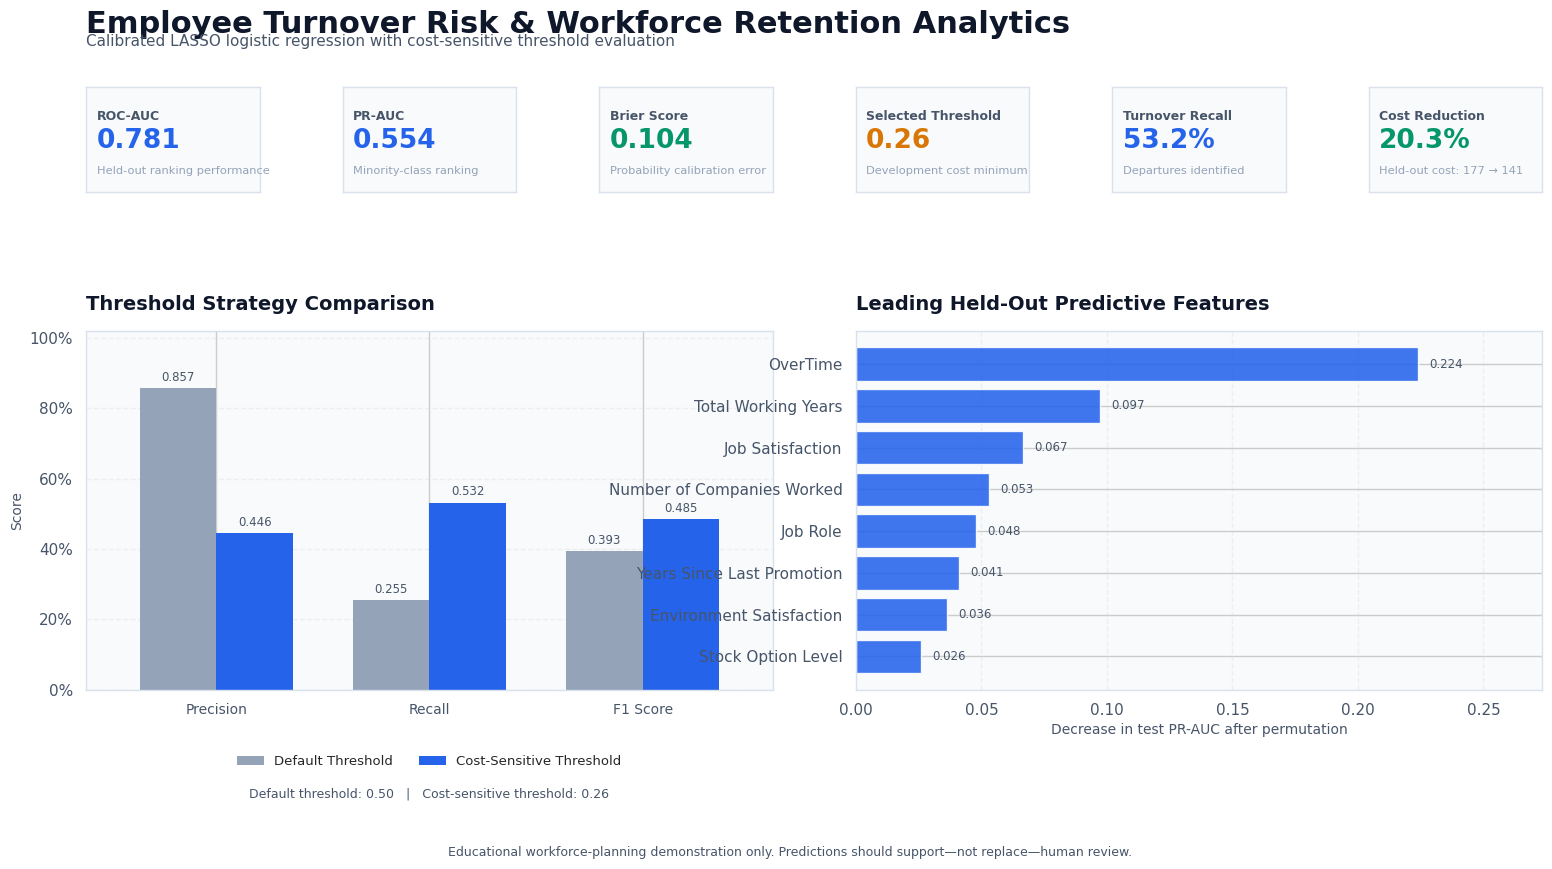

PROJECT OVERVIEW CREATED SUCCESSFULLY
Saved to: /content/employee-turnover-portfolio-visuals/employee-turnover-project-overview.png


In [29]:
# ============================================================
# EMPLOYEE TURNOVER PROJECT OVERVIEW DASHBOARD
# Fully standalone portfolio visualization
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import PercentFormatter

# ------------------------------------------------------------
# Output folder and filename
# ------------------------------------------------------------

output_folder = "/content/employee-turnover-portfolio-visuals"
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(
    output_folder,
    "employee-turnover-project-overview.png"
)

# ------------------------------------------------------------
# Verified held-out test results
# ------------------------------------------------------------

roc_auc_value = 0.781
pr_auc_value = 0.554
brier_value = 0.104

selected_threshold = 0.26
default_threshold = 0.50

selected_accuracy = 0.820
selected_balanced_accuracy = 0.703
selected_precision = 0.446
selected_recall = 0.532
selected_f1 = 0.485

default_accuracy = 0.874
default_balanced_accuracy = 0.624
default_precision = 0.857
default_recall = 0.255
default_f1 = 0.393

default_cost = 177
selected_cost = 141
cost_reduction = 20.3

# ------------------------------------------------------------
# Threshold comparison
# ------------------------------------------------------------

threshold_display = pd.DataFrame(
    {
        "Default Threshold": [
            default_precision,
            default_recall,
            default_f1
        ],
        "Cost-Sensitive Threshold": [
            selected_precision,
            selected_recall,
            selected_f1
        ]
    },
    index=[
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# ------------------------------------------------------------
# Verified permutation-importance results
# ------------------------------------------------------------

permutation_importance_df = pd.DataFrame({
    "Display Feature": [
        "OverTime",
        "Total Working Years",
        "Job Satisfaction",
        "Number of Companies Worked",
        "Job Role",
        "Years Since Last Promotion",
        "Environment Satisfaction",
        "Stock Option Level",
        "Department",
        "Job Involvement",
        "Job Level"
    ],
    "Mean Importance": [
        0.2241,
        0.0971,
        0.0667,
        0.0530,
        0.0478,
        0.0412,
        0.0364,
        0.0261,
        0.0247,
        0.0227,
        0.0172
    ],
    "Importance SD": [
        0.0277,
        0.0379,
        0.0197,
        0.0136,
        0.0298,
        0.0256,
        0.0253,
        0.0146,
        0.0281,
        0.0125,
        0.0274
    ]
})

importance_plot = (
    permutation_importance_df
    .sort_values(
        "Mean Importance",
        ascending=False
    )
    .head(8)
    .sort_values(
        "Mean Importance",
        ascending=True
    )
)

# ------------------------------------------------------------
# Color palette and styling
# ------------------------------------------------------------

navy = "#0F172A"
blue = "#2563EB"
slate = "#475569"
light_slate = "#94A3B8"
border = "#D9E2EC"
panel_background = "#F8FAFC"
white = "#FFFFFF"
green = "#059669"
amber = "#D97706"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
    "axes.labelcolor": slate,
    "xtick.color": slate,
    "ytick.color": slate
})

# ------------------------------------------------------------
# Create dashboard canvas
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(16, 9),
    facecolor=white
)

grid = GridSpec(
    nrows=2,
    ncols=6,
    figure=fig,
    height_ratios=[1.0, 3.4],
    hspace=0.60,
    wspace=0.48
)

fig.suptitle(
    "Employee Turnover Risk & Workforce Retention Analytics",
    fontsize=22,
    fontweight="bold",
    color=navy,
    x=0.06,
    y=0.965,
    ha="left"
)

fig.text(
    0.06,
    0.925,
    (
        "Calibrated LASSO logistic regression with "
        "cost-sensitive threshold evaluation"
    ),
    fontsize=11,
    color=slate,
    ha="left"
)

# ------------------------------------------------------------
# KPI card function
# ------------------------------------------------------------

def create_kpi_card(
    axis,
    title,
    value,
    subtitle,
    value_color=blue
):
    axis.set_facecolor(panel_background)

    for spine in axis.spines.values():
        spine.set_visible(True)
        spine.set_color(border)
        spine.set_linewidth(1.0)

    axis.set_xticks([])
    axis.set_yticks([])

    axis.text(
        0.06,
        0.78,
        title,
        transform=axis.transAxes,
        fontsize=9,
        fontweight="bold",
        color=slate,
        va="top"
    )

    axis.text(
        0.06,
        0.48,
        value,
        transform=axis.transAxes,
        fontsize=19,
        fontweight="bold",
        color=value_color,
        va="center"
    )

    axis.text(
        0.06,
        0.15,
        subtitle,
        transform=axis.transAxes,
        fontsize=8.2,
        color=light_slate,
        va="bottom"
    )

# ------------------------------------------------------------
# KPI cards
# ------------------------------------------------------------

kpi_cards = [
    (
        "ROC-AUC",
        f"{roc_auc_value:.3f}",
        "Held-out ranking performance",
        blue
    ),
    (
        "PR-AUC",
        f"{pr_auc_value:.3f}",
        "Minority-class ranking",
        blue
    ),
    (
        "Brier Score",
        f"{brier_value:.3f}",
        "Probability calibration error",
        green
    ),
    (
        "Selected Threshold",
        f"{selected_threshold:.2f}",
        "Development cost minimum",
        amber
    ),
    (
        "Turnover Recall",
        f"{selected_recall:.1%}",
        "Departures identified",
        blue
    ),
    (
        "Cost Reduction",
        f"{cost_reduction:.1f}%",
        f"Held-out cost: {default_cost} → {selected_cost}",
        green
    )
]

for column_index, card in enumerate(kpi_cards):
    card_axis = fig.add_subplot(
        grid[0, column_index]
    )

    create_kpi_card(
        axis=card_axis,
        title=card[0],
        value=card[1],
        subtitle=card[2],
        value_color=card[3]
    )

# ------------------------------------------------------------
# Threshold strategy comparison
# ------------------------------------------------------------

ax_threshold = fig.add_subplot(
    grid[1, :3]
)

ax_threshold.set_facecolor(
    panel_background
)

for spine in ax_threshold.spines.values():
    spine.set_color(border)
    spine.set_linewidth(1.0)

threshold_display.plot(
    kind="bar",
    ax=ax_threshold,
    color=[
        light_slate,
        blue
    ],
    width=0.72,
    edgecolor="none"
)

ax_threshold.set_title(
    "Threshold Strategy Comparison",
    fontsize=14,
    color=navy,
    loc="left",
    pad=15
)

ax_threshold.set_xlabel("")
ax_threshold.set_ylabel(
    "Score",
    fontsize=10
)

ax_threshold.set_ylim(
    0,
    1.02
)

ax_threshold.yaxis.set_major_formatter(
    PercentFormatter(xmax=1.0)
)

ax_threshold.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax_threshold.set_axisbelow(True)

ax_threshold.tick_params(
    axis="x",
    rotation=0,
    labelsize=10
)

# Add values above the bars.
for container in ax_threshold.containers:
    ax_threshold.bar_label(
        container,
        labels=[
            f"{bar.get_height():.3f}"
            for bar in container
        ],
        padding=3,
        fontsize=8.5,
        color=slate
    )

# Place the legend below the graph.
ax_threshold.legend(
    title="",
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2,
    fontsize=9.5
)

ax_threshold.text(
    0.5,
    -0.30,
    (
        f"Default threshold: {default_threshold:.2f}   |   "
        f"Cost-sensitive threshold: {selected_threshold:.2f}"
    ),
    transform=ax_threshold.transAxes,
    fontsize=9,
    color=slate,
    ha="center"
)

# ------------------------------------------------------------
# Feature-importance panel
# ------------------------------------------------------------

ax_importance = fig.add_subplot(
    grid[1, 3:]
)

ax_importance.set_facecolor(
    panel_background
)

for spine in ax_importance.spines.values():
    spine.set_color(border)
    spine.set_linewidth(1.0)

importance_bars = ax_importance.barh(
    importance_plot["Display Feature"],
    importance_plot["Mean Importance"],
    color=blue,
    alpha=0.88
)

ax_importance.set_title(
    "Leading Held-Out Predictive Features",
    fontsize=14,
    color=navy,
    loc="left",
    pad=15
)

ax_importance.set_xlabel(
    "Decrease in test PR-AUC after permutation",
    fontsize=10
)

ax_importance.set_ylabel("")

ax_importance.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax_importance.set_axisbelow(True)

maximum_importance = (
    importance_plot["Mean Importance"].max()
)

ax_importance.set_xlim(
    0,
    maximum_importance * 1.22
)

for bar, value in zip(
    importance_bars,
    importance_plot["Mean Importance"]
):
    ax_importance.text(
        value + maximum_importance * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=8.5,
        color=slate
    )

# ------------------------------------------------------------
# Footer
# ------------------------------------------------------------

fig.text(
    0.5,
    0.025,
    (
        "Educational workforce-planning demonstration only. "
        "Predictions should support—not replace—human review."
    ),
    ha="center",
    fontsize=9,
    color=slate
)

# Reserve room beneath the threshold chart for its legend.
plt.subplots_adjust(
    top=0.88,
    bottom=0.21,
    left=0.06,
    right=0.97,
    hspace=0.60,
    wspace=0.48
)

# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=white
)

plt.show()

print("=" * 70)
print("PROJECT OVERVIEW CREATED SUCCESSFULLY")
print("=" * 70)
print(f"Saved to: {output_path}")

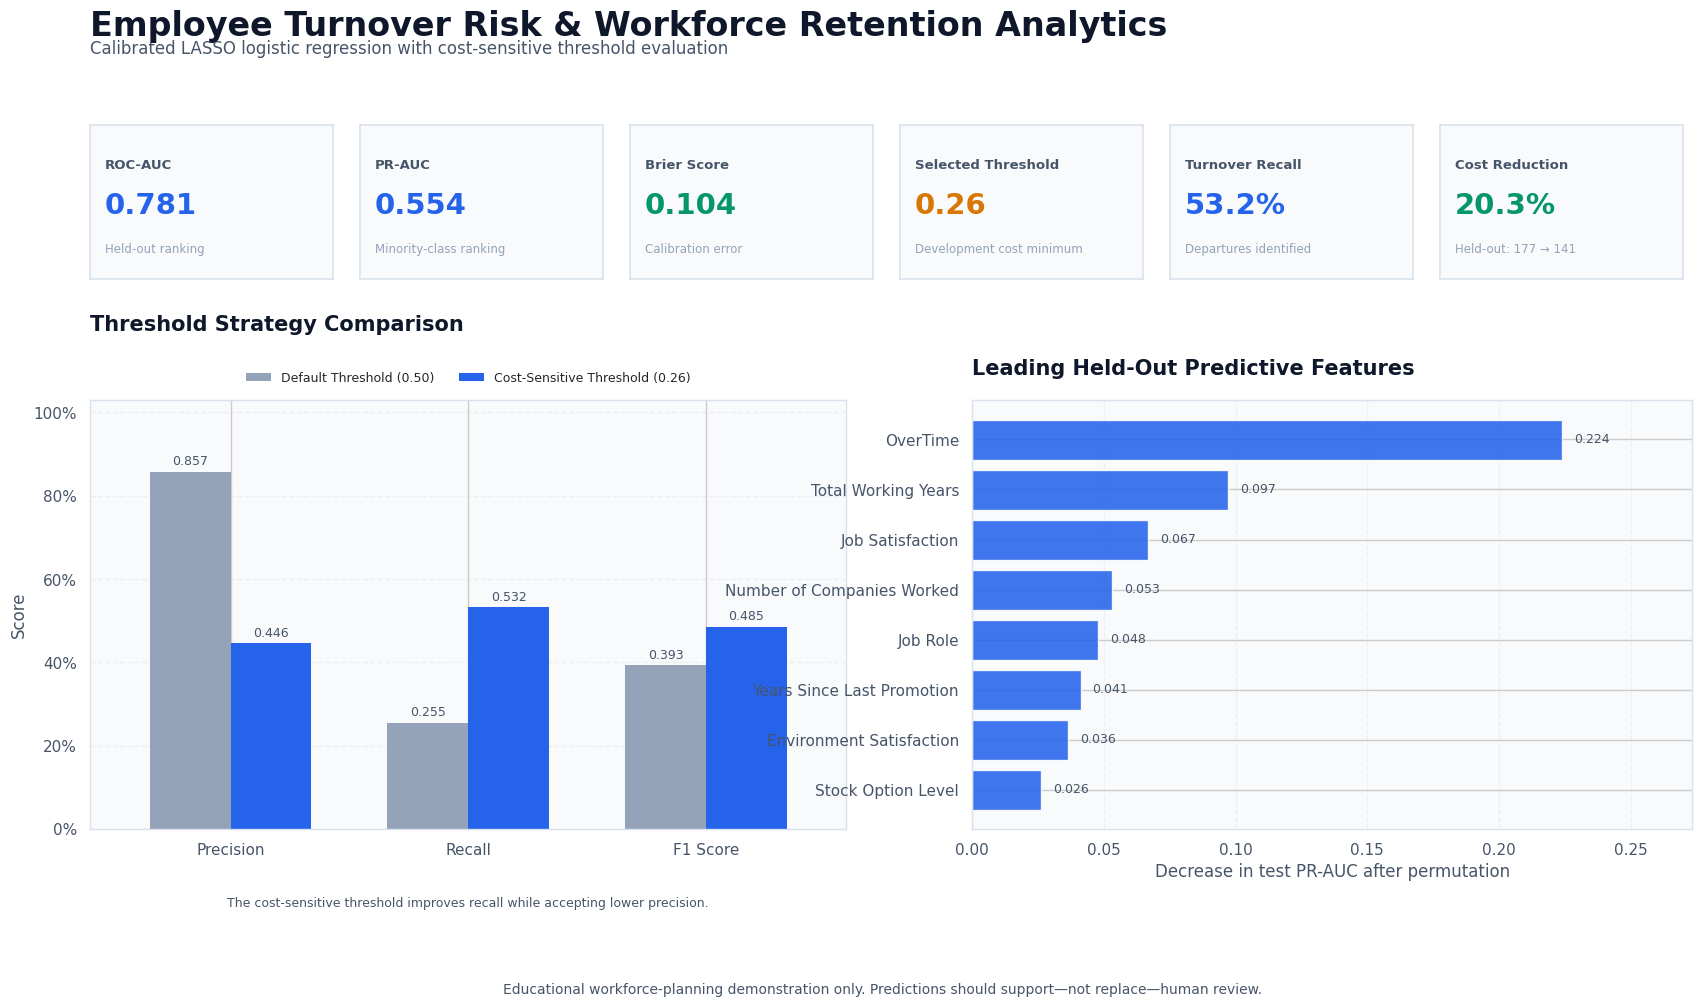

STANDALONE DASHBOARD CREATED
/content/employee-turnover-portfolio-visuals/employee-turnover-project-overview.png


In [30]:
# ============================================================
# STANDALONE EMPLOYEE TURNOVER DASHBOARD
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# ------------------------------------------------------------
# Output location
# ------------------------------------------------------------

output_folder = "/content/employee-turnover-portfolio-visuals"
os.makedirs(output_folder, exist_ok=True)

output_path = os.path.join(
    output_folder,
    "employee-turnover-project-overview.png"
)

# ------------------------------------------------------------
# Verified project results
# ------------------------------------------------------------

threshold_results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Default Threshold (0.50)": [
        0.857,
        0.255,
        0.393
    ],
    "Cost-Sensitive Threshold (0.26)": [
        0.446,
        0.532,
        0.485
    ]
}).set_index("Metric")

feature_results = pd.DataFrame({
    "Feature": [
        "OverTime",
        "Total Working Years",
        "Job Satisfaction",
        "Number of Companies Worked",
        "Job Role",
        "Years Since Last Promotion",
        "Environment Satisfaction",
        "Stock Option Level"
    ],
    "Importance": [
        0.2241,
        0.0971,
        0.0667,
        0.0530,
        0.0478,
        0.0412,
        0.0364,
        0.0261
    ]
})

feature_results = feature_results.sort_values(
    "Importance",
    ascending=True
)

# ------------------------------------------------------------
# Colors
# ------------------------------------------------------------

navy = "#0F172A"
blue = "#2563EB"
green = "#059669"
amber = "#D97706"
slate = "#475569"
light_slate = "#94A3B8"
border = "#D9E2EC"
panel_background = "#F8FAFC"
white = "#FFFFFF"

# ------------------------------------------------------------
# Create the figure
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(18, 11),
    facecolor=white
)

fig.suptitle(
    "Employee Turnover Risk & Workforce Retention Analytics",
    fontsize=24,
    fontweight="bold",
    color=navy,
    x=0.06,
    y=0.965,
    ha="left"
)

fig.text(
    0.06,
    0.925,
    (
        "Calibrated LASSO logistic regression with "
        "cost-sensitive threshold evaluation"
    ),
    fontsize=12,
    color=slate,
    ha="left"
)

# ------------------------------------------------------------
# KPI cards
# ------------------------------------------------------------

card_positions = [
    [0.06, 0.72, 0.135, 0.14],
    [0.21, 0.72, 0.135, 0.14],
    [0.36, 0.72, 0.135, 0.14],
    [0.51, 0.72, 0.135, 0.14],
    [0.66, 0.72, 0.135, 0.14],
    [0.81, 0.72, 0.135, 0.14]
]

cards = [
    (
        "ROC-AUC",
        "0.781",
        "Held-out ranking",
        blue
    ),
    (
        "PR-AUC",
        "0.554",
        "Minority-class ranking",
        blue
    ),
    (
        "Brier Score",
        "0.104",
        "Calibration error",
        green
    ),
    (
        "Selected Threshold",
        "0.26",
        "Development cost minimum",
        amber
    ),
    (
        "Turnover Recall",
        "53.2%",
        "Departures identified",
        blue
    ),
    (
        "Cost Reduction",
        "20.3%",
        "Held-out: 177 → 141",
        green
    )
]


def draw_card(position, title, value, subtitle, color):
    axis = fig.add_axes(position)

    axis.set_facecolor(panel_background)
    axis.set_xticks([])
    axis.set_yticks([])

    for spine in axis.spines.values():
        spine.set_color(border)
        spine.set_linewidth(1.2)

    axis.text(
        0.06,
        0.78,
        title,
        transform=axis.transAxes,
        fontsize=9.5,
        fontweight="bold",
        color=slate,
        va="top"
    )

    axis.text(
        0.06,
        0.48,
        value,
        transform=axis.transAxes,
        fontsize=21,
        fontweight="bold",
        color=color,
        va="center"
    )

    axis.text(
        0.06,
        0.15,
        subtitle,
        transform=axis.transAxes,
        fontsize=8.5,
        color=light_slate,
        va="bottom"
    )


for position, card in zip(
    card_positions,
    cards
):
    draw_card(
        position=position,
        title=card[0],
        value=card[1],
        subtitle=card[2],
        color=card[3]
    )

# ------------------------------------------------------------
# Threshold chart
# ------------------------------------------------------------

ax_threshold = fig.add_axes(
    [0.06, 0.22, 0.42, 0.39]
)

ax_threshold.set_facecolor(
    panel_background
)

for spine in ax_threshold.spines.values():
    spine.set_color(border)
    spine.set_linewidth(1.0)

threshold_results.plot(
    kind="bar",
    ax=ax_threshold,
    color=[
        light_slate,
        blue
    ],
    width=0.68,
    edgecolor="none"
)

ax_threshold.set_title(
    "Threshold Strategy Comparison",
    fontsize=15,
    fontweight="bold",
    color=navy,
    loc="left",
    pad=50
)

ax_threshold.set_xlabel("")
ax_threshold.set_ylabel("Score")
ax_threshold.set_ylim(0, 1.03)

ax_threshold.yaxis.set_major_formatter(
    PercentFormatter(1.0)
)

ax_threshold.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax_threshold.set_axisbelow(True)

ax_threshold.tick_params(
    axis="x",
    rotation=0
)

# Put the key above the graph, below the title.
ax_threshold.legend(
    title="",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    fontsize=9
)

for container in ax_threshold.containers:
    ax_threshold.bar_label(
        container,
        labels=[
            f"{bar.get_height():.3f}"
            for bar in container
        ],
        padding=3,
        fontsize=9,
        color=slate
    )

ax_threshold.text(
    0.5,
    -0.18,
    (
        "The cost-sensitive threshold improves recall "
        "while accepting lower precision."
    ),
    transform=ax_threshold.transAxes,
    ha="center",
    fontsize=9,
    color=slate
)

# ------------------------------------------------------------
# Feature importance chart
# ------------------------------------------------------------

ax_features = fig.add_axes(
    [0.55, 0.22, 0.40, 0.39]
)

ax_features.set_facecolor(
    panel_background
)

for spine in ax_features.spines.values():
    spine.set_color(border)
    spine.set_linewidth(1.0)

feature_bars = ax_features.barh(
    feature_results["Feature"],
    feature_results["Importance"],
    color=blue,
    alpha=0.88
)

ax_features.set_title(
    "Leading Held-Out Predictive Features",
    fontsize=15,
    fontweight="bold",
    color=navy,
    loc="left",
    pad=18
)

ax_features.set_xlabel(
    "Decrease in test PR-AUC after permutation"
)

ax_features.set_ylabel("")

ax_features.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax_features.set_axisbelow(True)

maximum_importance = (
    feature_results["Importance"].max()
)

ax_features.set_xlim(
    0,
    maximum_importance * 1.22
)

for bar, value in zip(
    feature_bars,
    feature_results["Importance"]
):
    ax_features.text(
        value + maximum_importance * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9,
        color=slate
    )

# ------------------------------------------------------------
# Footer
# ------------------------------------------------------------

fig.text(
    0.5,
    0.07,
    (
        "Educational workforce-planning demonstration only. "
        "Predictions should support—not replace—human review."
    ),
    ha="center",
    fontsize=10,
    color=slate
)

# ------------------------------------------------------------
# Save and show
# ------------------------------------------------------------

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=white
)

plt.show()

print("=" * 70)
print("STANDALONE DASHBOARD CREATED")
print("=" * 70)
print(output_path)